In [20]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix


In [21]:
df = pd.read_csv("../data_cleaning/out/20newsgroup_preprocessed.csv").fillna("")
X = df["text"]
y = df["target"]

# Split as done during training
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [22]:
model_dir = "../final_models"  # Adjust if your path is different
model_files = [f for f in os.listdir(model_dir) if f.endswith(".pkl")]

models = {}
for file in model_files:
    name = file.replace(".pkl", "")
    models[name] = joblib.load(os.path.join(model_dir, file))

In [23]:
results = []

for name, model in models.items():
    print(f"\nEvaluating model: {name}")
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Extract model type and vectorizer from name
    if "_tfidf" in name:
        vectorizer = "TF-IDF"
        model_name = name.replace("_tfidf", "")
    elif "_doc2vec" in name:
        vectorizer = "Doc2Vec"
        model_name = name.replace("_doc2vec", "")
    else:
        vectorizer = "Unknown"
        model_name = name

    results.append({
        "Model": model_name,
        "Vectorizer": vectorizer,
        "F1": f1
    })

    print(f"\n📊 Classification Report for {name}")
    print(classification_report(y_test, y_pred))



Evaluating model: dt_doc2vec

📊 Classification Report for dt_doc2vec
              precision    recall  f1-score   support

           0       0.06      0.04      0.05       160
           1       0.11      0.11      0.11       195
           2       0.13      0.10      0.11       197
           3       0.10      0.10      0.10       196
           4       0.16      0.19      0.17       193
           5       0.22      0.28      0.24       198
           6       0.18      0.10      0.13       195
           7       0.24      0.18      0.20       198
           8       0.13      0.24      0.17       199
           9       0.16      0.38      0.22       199
          10       0.12      0.17      0.14       200
          11       0.31      0.32      0.31       198
          12       0.08      0.07      0.07       197
          13       0.41      0.25      0.31       198
          14       0.30      0.22      0.25       197
          15       0.25      0.39      0.30       199
          1

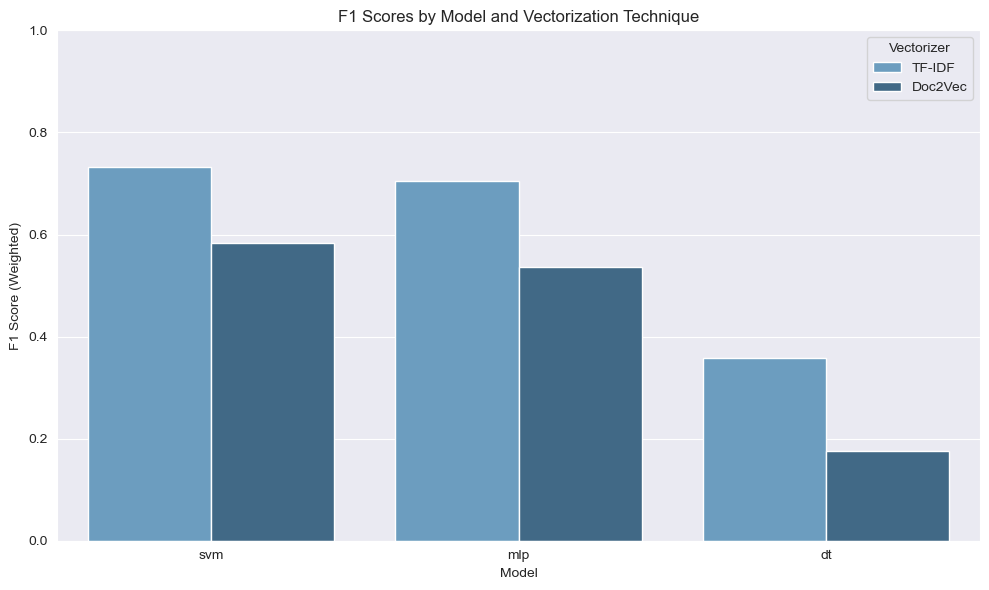

In [24]:
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)



plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="F1", hue="Vectorizer", palette="Blues_d")

plt.title("F1 Scores by Model and Vectorization Technique")
plt.ylabel("F1 Score (Weighted)")
plt.ylim(0, 1)
plt.legend(title="Vectorizer", loc="upper right")
plt.tight_layout()

plt.savefig("../evaluation/out/f1_scores_by_model.png", dpi=300)

plt.show()
